# Epidemic modeling: the SIR model

In this notebook we build and explore a simple **SIR** epidemic model (**S**usceptible, **I**nfected, **R**ecovered) using [basiCO](https://basico.readthedocs.io/en/latest/index.html), a Python interface to [COPASI](https://copasi.org/).

**Learning objectives**

By the end of this notebook you should be able to:
- Translate a compartmental epidemic model into reactions and build it in basiCO
- Run deterministic and stochastic simulations of the model
- Use parameter scans to explore how model parameters shape an epidemic
- Interpret the effective reproduction number $R_e$ and the epidemic threshold $R_e = 1$

## The model

The SIR model can be written as two reactions:

```
S + I -> 2 I      (Infection)
I     -> R        (Recovery)
```

or, equivalently, as a system of ordinary differential equations:

$$\frac{dS}{dt} = -\beta S I \qquad \frac{dI}{dt} = \beta S I - \gamma I \qquad \frac{dR}{dt} = \gamma I$$

- $\beta$ is the **transmission rate**, in units of $1/(\text{day}\cdot\text{person})$. It depends on the population's contact rate and on how transmissible the disease is per contact.
- $\gamma$ is the **recovery rate**, in units of $1/\text{day}$. Its inverse, $1/\gamma$, is the average duration of infection.

A key quantity in epidemiology is the **effective reproduction number**

$$R_e(t) = \frac{\beta}{\gamma}\, S(t)$$

which tells you how many new infections one infected person is currently causing, on average. The epidemic grows as long as $R_e > 1$ and starts to decline once $R_e$ falls below 1 - this is the moment the infection peak has passed.

In [2]:
import sys
if '../..' not in sys.path:
    sys.path.append('../..')

from basico import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Building the model

In [3]:
new_model(name='SIR');
add_reaction('Infection', 'S + I -> 2 I');  # don't forget the space between the number and the species
add_reaction('Recovery', 'I -> R');

### Set model units

We set the time unit to days, the volume unit to 1 (there is no physical volume in this model), and the quantity unit to `#`, meaning "number of individuals" (the COPASI default is `mol`, which is more suitable for biochemical reactions).

In [4]:
set_model_unit(time_unit='d', volume_unit=1, quantity_unit='#')
get_model_units()

{'time_unit': 'd',
 'quantity_unit': '#',
 'length_unit': 'm',
 'area_unit': 'm²',
 'volume_unit': '1'}

### Set initial values

Initially there is only one infected person (patient zero), and everyone else is susceptible.

In [5]:
set_species('S', initial_particle_number=99)
set_species('I', initial_particle_number=1)
set_species('R', initial_particle_number=0)
get_species().initial_particle_number

name
I     1.0
S    99.0
R     0.0
Name: initial_particle_number, dtype: float64

### Set parameters

We map the reaction rate constants (`k1`) to the named global parameters `beta` and `gamma`, so we can refer to them by name and change them easily later.

In [6]:
beta = 0.02
gamma = 0.2
add_parameter('beta', initial_value=beta)
add_parameter('gamma', initial_value=gamma)

set_reaction_parameters('(Infection).k1', mapped_to='beta')
set_reaction_parameters('(Recovery).k1', mapped_to='gamma')
get_reaction_parameters()

,value,reaction,type,mapped_to
name,,,,
(Infection).k1,0.02,Infection,global,beta
(Recovery).k1,0.20,Recovery,global,gamma


### Explore the model

A couple of functions to double-check the model was built as intended.

In [7]:
get_stoichiometry_matrix()

,(Infection),(Recovery)
I,1.0,-1.0
S,-1.0,0.0
R,0.0,1.0


In [8]:
get_reactions()

,scheme,flux,particle_flux,function,key,sbml_id,display_name,mapping
name,,,,,,,,
Infection,S + I -> 2 * I,0.0,0.0,Mass action (irreversible),Reaction_0,,(Infection),"{'k1': 'beta', 'substrate': ['S', 'I']}"
Recovery,I -> R,0.0,0.0,Mass action (irreversible),Reaction_1,,(Recovery),"{'k1': 'gamma', 'substrate': 'I'}"


## Run a time course simulation

We now simulate the model deterministically over 40 days and track the effective reproduction number $R_e(t) = \dfrac{\beta}{\gamma} S(t)$ alongside it.

In [9]:
result = run_time_course(duration=40, method='deterministic', use_numbers=True)

# effective reproduction number: epidemic grows while Re > 1 and
# starts to decline once Re drops below 1
result['Re'] = (beta / gamma) * result.S

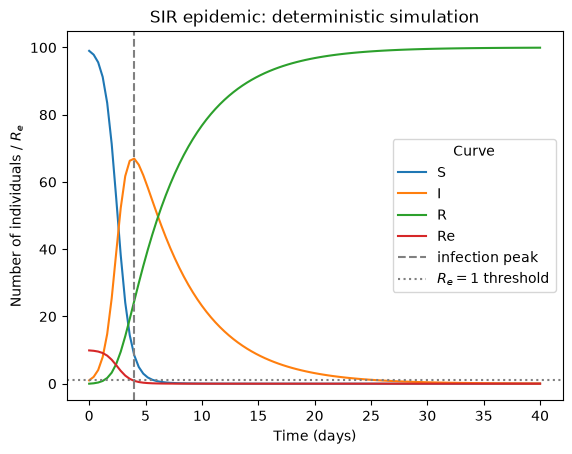

In [10]:
fig, ax = plt.subplots()
result[['S', 'I', 'R', 'Re']].plot(ax=ax)

peak_day = result.index[np.argmax(result.I)]
ax.axvline(peak_day, color='grey', linestyle='--', label='infection peak')
ax.axhline(1, color='grey', linestyle=':', label='$R_e = 1$ threshold')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Number of individuals / $R_e$')
ax.set_title('SIR epidemic: deterministic simulation')
ax.legend(title='Curve')

### Parameter scan

A parameter scan lets us easily test the effect of a parameter by re-running the simulation for several values and comparing the resulting curves.

We write one small helper function, `scan_parameter`, and reuse it below for both $\beta$ and $\gamma$.

In [11]:
def scan_parameter(param_name, values, species='I', duration=40):
    """Run a deterministic time course for each value of `param_name` and
    collect the `species` trajectory into a single, tidy DataFrame.

    Restores the model's original parameter value once done.
    """
    original_value = get_parameters(param_name).initial_value.iloc[0]

    frames = []
    for v in values:
        set_parameters(param_name, initial_value=v)
        r = run_time_course(duration=duration,
                            method='deterministic',
                            use_numbers=True)
        r = r[[species]].copy()
        r[param_name] = v
        frames.append(r)

    set_parameters(param_name, initial_value=original_value)
    return pd.concat(frames)


def plot_scan(scan_result, param_name, ylabel='Infected individuals'):
    fig, ax = plt.subplots()
    for v, g in scan_result.groupby(param_name):
        ax.plot(g.index, g['I'], label=f'{param_name}={v:.3g}')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(ylabel)
    ax.legend(title=param_name)
    return fig, ax

Text(0.5, 1.0, 'Effect of the transmission rate $\\beta$')

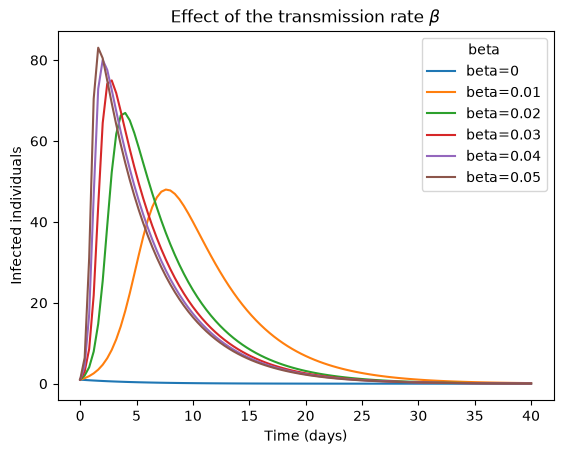

In [12]:
# Effect of the transmission rate beta (recovery rate gamma held fixed)
beta_values = np.linspace(0, 0.05, 6)
beta_scan = scan_parameter('beta', beta_values)
fig, ax = plot_scan(beta_scan, 'beta')
ax.set_title('Effect of the transmission rate $\\beta$')

Text(0.5, 1.0, 'Effect of the recovery rate $\\gamma$')

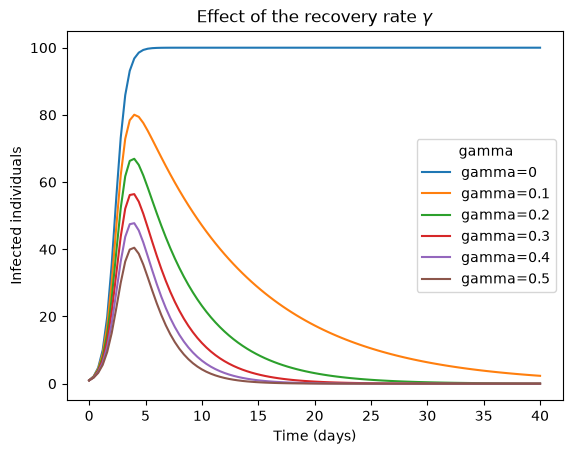

In [13]:
# Effect of the recovery rate gamma (transmission rate beta held fixed)
gamma_values = np.linspace(0, 0.5, 6)
gamma_scan = scan_parameter('gamma', gamma_values)
fig, ax = plot_scan(gamma_scan, 'gamma')
ax.set_title('Effect of the recovery rate $\\gamma$')

**Something to think about:** how does each parameter affect the *height* of the infection peak versus its *timing*? Does this match what you'd expect from the $R_e = \dfrac{\beta}{\gamma}S$ formula above?

### Stochastic simulation

In real life, things are not perfectly deterministic - there is an effect of chance, especially when the number of infected individuals is small (e.g., right at the start of the epidemic). To capture this, we can run a **stochastic simulation**, which uses random numbers to decide when each reaction event happens.

Text(0.5, 1.0, 'A single stochastic realization')

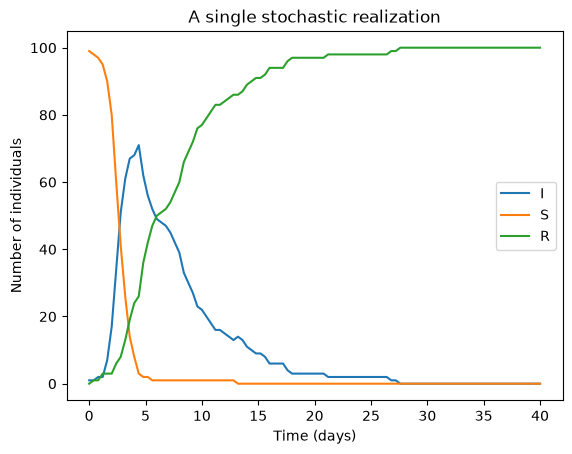

In [14]:
result = run_time_course(duration=40, method='stochastic', use_numbers=True)
ax = result.plot()
ax.set_xlabel('Time (days)')
ax.set_ylabel('Number of individuals')
ax.set_title('A single stochastic realization')

Because each stochastic run is different, a single realization does not tell the whole story. To get a representative picture, we rerun the simulation many times and look at the *spread* of outcomes - similar in spirit to a confidence interval.

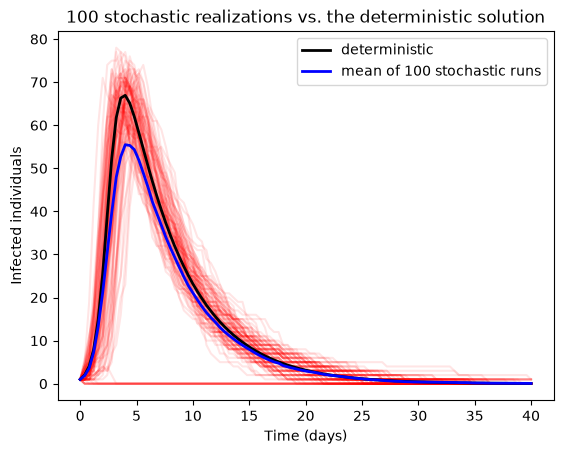

In [15]:
n_runs = 100
runs = []
fig, ax = plt.subplots()

for i in range(n_runs):
    result = run_time_course(duration=40, method='stochastic', use_numbers=True, use_seed=False)
    runs.append(result['I'])
    ax.plot(result.index, result['I'], color='red', alpha=0.1)

# overlay the deterministic trajectory and the mean of the stochastic runs for comparison
deterministic = run_time_course(duration=40, method='deterministic', use_numbers=True)
ax.plot(deterministic.index, deterministic['I'], color='black', linewidth=2, label='deterministic')

mean_I = pd.concat(runs, axis=1).mean(axis=1)
ax.plot(mean_I.index, mean_I, color='blue', linewidth=2, label=f'mean of {n_runs} stochastic runs')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Infected individuals')
ax.set_title(f'{n_runs} stochastic realizations vs. the deterministic solution')
ax.legend()

## Homework: immunization and waning immunity

### Task

Extend the SIR model to account for **immunization** and **waning immunity** (people who are immune can eventually become susceptible again).

Use this model to represent two public-health interventions, and compare them:

1. **Rate of immunization** - i.e. vaccination of susceptible people.
2. **Booster shots** - among people who are already immune (recovered or vaccinated), a booster slows down the loss of immunity

It's up to you to decide how to represent these mechanisms as reactions and parameters in basiCO, and how to design simulations that isolate the effect of each intervention.

### What to submit

Upload both of the following:

- **Completed Jupyter notebook** containing your extended model, simulations, and plots (with axis labels and legends).
- **Short PDF report** (max. 2 pages) describing:
  - the model (equations and/or reaction scheme, and the parameter values you used),
  - the plots comparing the two interventions,
  - your conclusion and reasoning.

### Grading criteria

| Criterion | What we're looking for |
|---|---|
| Model correctness |	Your reactions and parameters correctly capture immunization and waning immunity, and the model behaves as expected |
| Experimental design | Comparisons isolate one intervention at a time (all else held equal) |
| Analysis | Clear, correctly-labeled plots and a sensible choice of comparison metric(s) |
| Conclusion | Answer is supported by the simulation results, not just intuition |
| Clarity | Report is concise, well-organized, and readable within the 2-page limit |
